# 2. FEct — Minimal Workflow

This notebook demonstrates the minimal user API:

- Estimate: `out = fect(...)`
- Print summary: `print(out)`
- Plot event-study or calendar ATT: `out.plot(type='gap' | 'calendar')`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fect import fect  # minimal API
from fect import data as fdata

# Use packaged simulated dataset
sim = fdata.simdata()

required = {"id", "time", "Y", "D"}
missing = required - set(sim.columns)
if missing:
    raise ValueError(f"simdata is missing required columns: {missing}")

cols = ["id", "time", "Y", "D"]
X_cols = []
for c in ["X1", "X2"]:
    if c in sim.columns:
        cols.append(c)
        X_cols.append(c)

df = sim[cols].copy()
print(df.head())


    id  time          Y  D        X1        X2
0  101     1  12.158520  0  1.299638  0.598438
1  101     2  15.083915  0 -0.029369 -0.274701
2  101     3  14.850594  0 -2.236622  0.526919
3  101     4  16.579266  0  0.545030  0.830335
4  101     5   6.784694  0  0.830842 -3.091013


#> Call:
#>   fect(formula = Y ~ D + X1 + X2, index = ('id', 'time'), force = 'two-way', method = 'fe')
#>
#> ATT:
#>
#>                                    ATT
#>   Tr obs equally weighted        5.121
#>   Tr units equally weighted      3.622
#>
#> Covariates:
#>                                   Coef
#>   X1                             1.015
#>   X2                             2.937


<Axes: title={'center': 'Estimated ATT (FEct)'}, xlabel="Time Since the Treatment's Onset", ylabel='Effect of D on Y'>

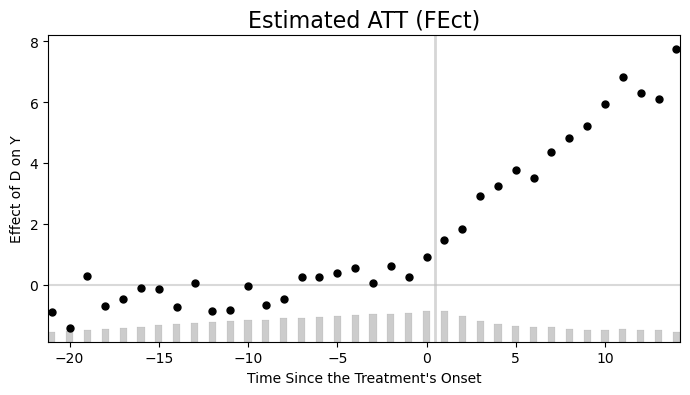

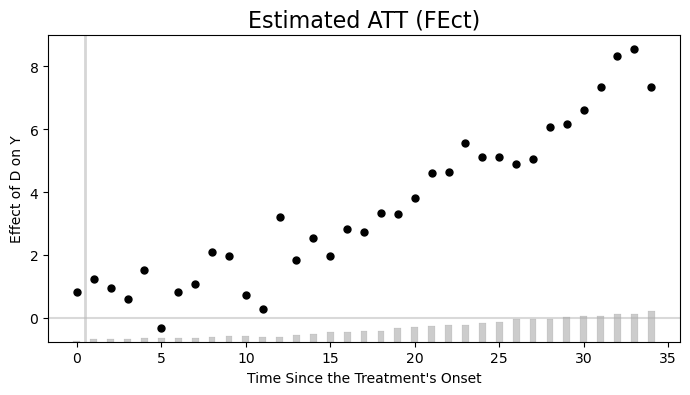

In [ ]:
# Estimate without SE; plot won't show CI bands
out = fect(
    data=df,
    Y="Y",
    D="D",
    X=X_cols if len(X_cols) > 0 else None,
    index=("id", "time"),
    method="fe",
    se=False,
)

print(out)  # minimal summary (no SE section)

out.plot(type='gap')

out.plot(type='calendar');


#> Call:
#>   fect(formula = Y ~ D + X1 + X2, index = ('id', 'time'), force = 'two-way', method = 'fe')
#>
#> ATT:
#>
#>                                    ATT    S.E. CI.lower CI.upper p.value
#>   Tr obs equally weighted        5.121  0.3143    4.505    5.737       0
#>   Tr units equally weighted      3.622  0.2643    3.104    4.140       0
#>
#> Covariates:
#>                                   Coef    S.E. CI.lower CI.upper p.value
#>   X1                             1.015 0.03777   0.9412   1.0892       0
#>   X2                             2.937 0.03533   2.8677   3.0062       0


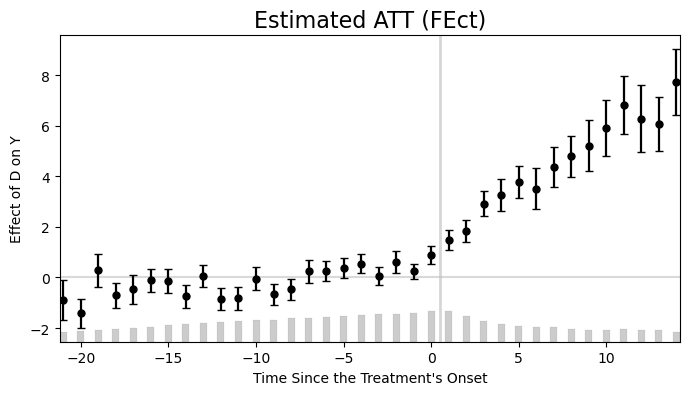

In [3]:
# Estimate with SE; print shows SE/CI and plots draw CI
out_bootstrap = fect(
    df, Y="Y", D="D", X=X_cols, index=("id","time"), method="fe",
    se=True, vartype="bootstrap", nboots=200, seed=123
)
print(out_bootstrap)
out_bootstrap.plot(type='gap');



#> Call:
#>   fect(formula = Y ~ D + X1 + X2, index = ('id', 'time'), force = 'two-way', method = 'fe')
#>
#> ATT:
#>
#>                                    ATT    S.E. CI.lower CI.upper p.value
#>   Tr obs equally weighted        5.121  0.3460    4.443    5.799       0
#>   Tr units equally weighted      3.622  0.2807    3.072    4.172       0
#>
#> Covariates:
#>                                   Coef    S.E. CI.lower CI.upper p.value
#>   X1                             1.015 0.03515   0.9463   1.0841       0
#>   X2                             2.937 0.03434   2.8696   3.0042       0


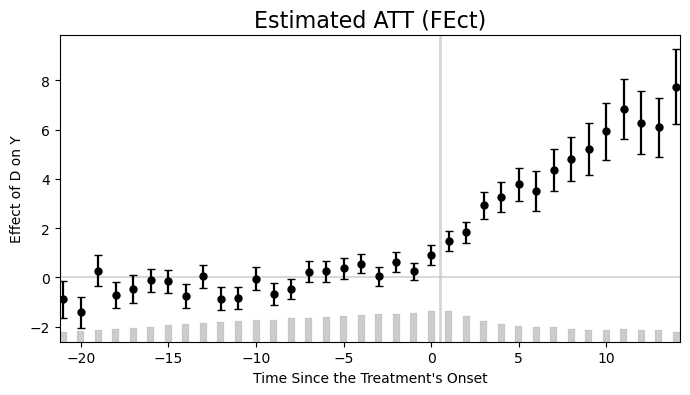

In [4]:
# Estimate with SE; print shows SE/CI and plots draw CI
out_jackknife = fect(
    df, Y="Y", D="D", X=X_cols, index=("id","time"), method="fe",
    se=True, vartype="jackknife", seed=123
)
print(out_jackknife)
out_jackknife.plot(type='gap');

